# F13: Linjeintegral og konservative vektorfelt

Denne notatboken bygger direkte videre på `F11_Gradient_Vektorfelt_Divergens_Curl.ipynb` (vektorfelt, gradient, divergens, curl) og `F12_Potensialfunksjoner_Stromlinjer.ipynb` (potensialfunksjoner, rotasjonsfrie felt, strømlinjer). Her ser vi på

1. **linjeintegral** av et vektorfelt langs en kurve,
2. hvordan linjeintegralet av et *gradientfelt* ikke avhenger av hvilken vei vi velger -- bare av start- og endepunkt,
3. den presise definisjonen av **konservative vektorfelt**, og
4. en advarsel om at $\operatorname{curl}\vec F=0$ ikke alltid er nok til å garantere at et felt er konservativt.

In [1]:
import numpy as np                      # numerisk regning
import matplotlib.pyplot as plt         # plotting
import sympy as sp                      # symbolsk regning (integrasjon, derivasjon, ...)

%matplotlib inline
plt.rcParams["figure.figsize"] = (6, 6)   # default figurstørrelse for resten av notatboken

x, y, t = sp.symbols('x y t', real=True)  # x, y: koordinater. t: parameter langs en kurve

## 1. Linjeintegral av et vektorfelt

Gitt et vektorfelt $\vec F(x,y)=(P(x,y),Q(x,y))$ og en kurve $C$ parametrisert ved $\gamma(t)=(x(t),y(t))$, $t\in[a,b]$, er **linjeintegralet** av $\vec F$ langs $C$ definert som

$$\int_C \vec F\cdot d\vec r \;=\; \int_a^b \vec F(\gamma(t))\cdot\gamma'(t)\,dt \;=\; \int_a^b \Big[P(x(t),y(t))\,x'(t) + Q(x(t),y(t))\,y'(t)\Big]\,dt.$$

Fysisk tolkning: dersom $\vec F$ er en kraft, er dette **arbeidet** kraften utfører når vi beveger oss langs $C$.

Vi tester dette på rotasjonsfeltet $\vec F(x,y)=(y,-x)$ fra F11 (der $\operatorname{curl}\vec F=-2\neq0$, så dette er *ikke* et gradientfelt), langs to forskjellige kurver mellom samme to punkter $(1,0)$ og $(0,1)$: en kvart sirkelbue, og en rett linje.

In [2]:
P_expr, Q_expr = y, -x   # feltet F = (y, -x)

# --- Kurve 1: kvart sirkelbue fra (1,0) til (0,1), t fra 0 til pi/2 ---
xt, yt = sp.cos(t), sp.sin(t)
dx_dt, dy_dt = sp.diff(xt, t), sp.diff(yt, t)

# Sett kurven inn i feltet, og ta prikkproduktet med den tangentielle hastigheten (x'(t), y'(t))
integrand_bue = sp.simplify(P_expr.subs({x: xt, y: yt})*dx_dt + Q_expr.subs({x: xt, y: yt})*dy_dt)
I_bue = sp.integrate(integrand_bue, (t, 0, sp.pi/2))
print("Kvart sirkelbue: integrand =", integrand_bue, " linjeintegral =", I_bue)

# --- Kurve 2: rett linje fra (1,0) til (0,1), t fra 0 til 1 ---
xt2, yt2 = 1 - t, t
dx2_dt, dy2_dt = sp.diff(xt2, t), sp.diff(yt2, t)

integrand_linje = sp.simplify(P_expr.subs({x: xt2, y: yt2})*dx2_dt + Q_expr.subs({x: xt2, y: yt2})*dy2_dt)
I_linje = sp.integrate(integrand_linje, (t, 0, 1))
print("Rett linje:      integrand =", integrand_linje, " linjeintegral =", I_linje)

print()
print(f"Samme to endepunkt, men ulikt resultat: {I_bue} (bue) vs. {I_linje} (linje)")

Kvart sirkelbue: integrand = -1  linjeintegral = -pi/2
Rett linje:      integrand = -1  linjeintegral = -1

Samme to endepunkt, men ulikt resultat: -pi/2 (bue) vs. -1 (linje)


Legg merke til at de to kurvene har *samme* start- og endepunkt, men gir *forskjellig* linjeintegral ($-\pi/2$ mot $-1$). Dette er helt som forventet for et felt med $\operatorname{curl}\vec F\neq0$: linjeintegralet avhenger av hvilken vei vi velger, ikke bare av endepunktene.

**Oppgave (løses i forelesningen):** Regn linjeintegralet av $\vec F=(y,-x)$ langs den *rette linja* fra $(1,0)$ til $(0,-1)$ (motsatt side). Får du samme svar som for kvart sirkelbuen ovenfor?

In [3]:
# Skriv koden her


## 2. Linjeintegralet av et gradientfelt er stiuavhengig

Nå gjør vi det samme med et **gradientfelt**: $\vec F(x,y)=(2x,2y)=\nabla f$, der $f(x,y)=x^2+y^2$ (kjenner vi igjen fra F12). Vi velger to punkter $A=(0,0)$ og $B=(1,2)$, og regner linjeintegralet langs to helt forskjellige kurver mellom dem: en rett linje, og en parabel.

In [4]:
Pg_expr, Qg_expr = 2*x, 2*y   # gradientfeltet F = grad f, f = x^2+y^2
f_expr = x**2 + y**2

A_punkt, B_punkt = (0, 0), (1, 2)

# --- Kurve 1: rett linje fra A til B, t fra 0 til 1 ---
xt1, yt1 = t, 2*t
ig1 = sp.simplify(Pg_expr.subs({x: xt1, y: yt1})*sp.diff(xt1, t) + Qg_expr.subs({x: xt1, y: yt1})*sp.diff(yt1, t))
I1 = sp.integrate(ig1, (t, 0, 1))
print("Rett linje:  linjeintegral =", I1)

# --- Kurve 2: parabel fra A til B, t fra 0 til 1 ---
xt2, yt2 = t, 2*t**2
ig2 = sp.simplify(Pg_expr.subs({x: xt2, y: yt2})*sp.diff(xt2, t) + Qg_expr.subs({x: xt2, y: yt2})*sp.diff(yt2, t))
I2 = sp.integrate(ig2, (t, 0, 1))
print("Parabel:     linjeintegral =", I2)

# --- Sammenlign med f(B) - f(A) ---
f_diff = f_expr.subs({x: B_punkt[0], y: B_punkt[1]}) - f_expr.subs({x: A_punkt[0], y: A_punkt[1]})
print("f(B) - f(A)  =", f_diff)

Rett linje:  linjeintegral = 5
Parabel:     linjeintegral = 5
f(B) - f(A)  = 5


Begge kurvene gir *nøyaktig* samme linjeintegral, nemlig $5$ -- og det er nøyaktig $f(B)-f(A)$! Dette er ingen tilfeldighet: det er **hovedsetningen for linjeintegraler** (også kjent fra vanlig integrasjon, som fundamentalteoremet). Grunnen er kjerneregelen: langs en kurve $\gamma(t)$ har vi

$$\frac{d}{dt}f(\gamma(t)) = \nabla f(\gamma(t))\cdot\gamma'(t),$$

så integralet av høyresiden (som er nøyaktig integranden i linjeintegralet, når $\vec F=\nabla f$) blir bare $f(\gamma(b))-f(\gamma(a))=f(B)-f(A)$, uansett hvilken vei $\gamma$ vi valgte mellom $A$ og $B$.

## 3. Konservative vektorfelt -- definisjonen

Vi er nå klare for den presise definisjonen. Et vektorfelt $\vec F$ kalles **konservativt** dersom linjeintegralet $\int_C\vec F\cdot d\vec r$ mellom to punkter $A$ og $B$ er **det samme** uansett hvilken kurve $C$ vi velger mellom dem -- akkurat som vi så for gradientfeltet ovenfor.

Dette er ekvivalent med to andre, ofte nyttige, formuleringer:

* $\displaystyle\oint_C \vec F\cdot d\vec r = 0$ for **enhver lukket kurve** $C$ (siden en lukket kurve kan deles i to veier mellom samme to punkter, som da må gi likt -- og dermed motsatt like -- bidrag),
* det finnes en **potensialfunksjon** $f$ slik at $\vec F=\nabla f$.

Fra F12 vet vi at ethvert gradientfelt er **rotasjonsfritt**: $\operatorname{curl}(\nabla f)=0$. Det gir oss en **nødvendig betingelse**: er $\vec F$ konservativt, må $\operatorname{curl}\vec F=0$ overalt. Spørsmålet er om det er *tilstrekkelig* også -- det ser vi på nå.

In [5]:
def curl_2d(P_expr, Q_expr):
    # curl F (2D, skalar) = dQ/dx - dP/dy
    return sp.simplify(sp.diff(Q_expr, x) - sp.diff(P_expr, y))

# Sjekk på gradientfeltet vårt: F = (2x, 2y) = grad(x^2+y^2)
print("curl (2x, 2y) =", curl_2d(Pg_expr, Qg_expr), "-> konsistent med at feltet er konservativt")

curl (2x, 2y) = 0 -> konsistent med at feltet er konservativt


## 4. En felle: curl$=0$ er ikke alltid nok

Fra F11 og F12 kjenner vi igjen feltet

$$\vec F(x,y) = \frac{(y,-x)}{x^2+y^2}$$

(nøyaktig **Eksempel 2.8** i kompendiet). Vi viste der at $\operatorname{curl}\vec F=0$ overalt på $\R^2\setminus\{\vec 0\}$. Betyr det at $\vec F$ er konservativt? La oss bruke *definisjonen* -- linjeintegralet -- til å teste det direkte, i stedet for å bare stole på curl.

Først: finnes det en potensialfunksjon? Vi bruker samme oppskrift som i F12 (integrer $P$ med hensyn på $x$, juster med $g(y)$):

In [6]:
def finn_potensial(P_expr, Q_expr):
    '''Finner (om mulig) f slik at grad f = (P, Q), med Sympy. Samme oppskrift som i F12.'''
    g = sp.Function('g')
    f_kandidat = sp.integrate(P_expr, x) + g(y)
    gprime = sp.solve(sp.Eq(sp.diff(f_kandidat, y), Q_expr), sp.diff(g(y), y))
    if not gprime:
        return None
    g_expr = sp.integrate(gprime[0], y)
    return sp.simplify(sp.integrate(P_expr, x) + g_expr)

P_v, Q_v = y/(x**2 + y**2), -x/(x**2 + y**2)   # feltet vårt
print("curl F =", curl_2d(P_v, Q_v))

f_forsøk = finn_potensial(P_v, Q_v)
print("Potensial funnet av finn_potensial:", f_forsøk)

# Sjekk 1: gir gradienten til f_forsøk faktisk tilbake (P_v, Q_v)?
grad_sjekk = (sp.simplify(sp.diff(f_forsøk, x) - P_v), sp.simplify(sp.diff(f_forsøk, y) - Q_v))
print("grad(f_forsøk) - (P, Q) =", grad_sjekk)

# Sjekk 2: er f_forsøk faktisk reelt i et vanlig punkt (ikke bare et komplekst tilfeldighetstreff)?
punkt = {x: 1.3, y: 0.7}
verdi = complex(f_forsøk.subs(punkt))
print(f"f_forsøk i punktet {punkt}: {verdi}  (imaginærdel ~ {verdi.imag:.2e})")

curl F = 0
Potensial funnet av finn_potensial: atan(x/y)
grad(f_forsøk) - (P, Q) = (0, 0)
f_forsøk i punktet {x: 1.3, y: 0.7}: (1.0768549578753155+0j)  (imaginærdel ~ 0.00e+00)


`finn_potensial` returnerer altså **ikke** `None`: Sympy finner et uttrykk -- typisk noe i familien til $-\arctan2(y,x)=-\theta$ (minus polarvinkelen) eller $\arctan(x/y)$, avhengig av hvilken løsningsvei Sympy velger -- der sjekk 1 viser at gradienten stemmer eksakt med $\vec F$, og sjekk 2 viser at uttrykket faktisk er *reelt* i et vanlig punkt. Så $f_{\text{forsøk}}$ *er* et gyldig potensial -- men bare **lokalt**, altså i en omegn rundt ethvert enkelt punkt utenfor origo. Alle disse uttrykkene er i praksis den samme *polarvinkelen* $\theta$, bare uttrykt/forskjøvet på litt forskjellige måter. Problemet er at $\theta$ ikke er en veldefinert, kontinuerlig funksjon på hele $\R^2\setminus\{\vec 0\}$: går vi én hel runde rundt origo, øker $\theta$ med $2\pi$, og vi ender ikke opp der vi startet i $f$-verdi.

La oss nå bruke *definisjonen* fra avsnitt 3 direkte: regn linjeintegralet av $\vec F$ rundt en lukket kurve som går rundt origo. Er $\vec F$ konservativt, skal dette gi null.

In [7]:
# Lukket kurve: enhetssirkelen, mot klokka, t fra 0 til 2*pi
xt3, yt3 = sp.cos(t), sp.sin(t)

integrand = P_v.subs({x: xt3, y: yt3}) * sp.diff(xt3, t) + Q_v.subs({x: xt3, y: yt3}) * sp.diff(yt3, t)
integrand = sp.simplify(integrand)
print("Integrand langs enhetssirkelen:", integrand)

linjeintegral = sp.integrate(integrand, (t, 0, 2*sp.pi))
print(r"Linjeintegral av F rundt enhetssirkelen (mot klokka) =", linjeintegral, "=", float(linjeintegral))

Integrand langs enhetssirkelen: -1
Linjeintegral av F rundt enhetssirkelen (mot klokka) = -2*pi = -6.283185307179586


Linjeintegralet blir $-2\pi\neq0$ -- ikke null, selv om kurven er lukket. Ifølge definisjonen i avsnitt 3 betyr dette at $\vec F$ **ikke er konservativt**, til tross for at $\operatorname{curl}\vec F=0$ i ethvert enkeltpunkt der feltet er definert!

Legg merke til at $-2\pi$ er nøyaktig det polarvinkelen $\theta=-f_{\text{forsøk}}$ endrer seg med når vi går én hel runde rundt origo -- linjeintegralet "fanger opp" akkurat det spranget som gjør at potensialet ikke er globalt veldefinert.

**Den dypere forklaringen:** curl$=0$ er en nødvendig betingelse for at et felt skal være konservativt, men den er bare *tilstrekkelig* dersom definisjonsmengden er **enkeltsammenhengende** (uten "hull"). Definisjonsmengden $\R^2\setminus\{\vec 0\}$ har et hull i origo, og da holder ikke omvendingen av "curl av gradient er null". Dette er nøyaktig poenget som også diskuteres i kompendiets Eksempel 2.8 -- ordet "irrotasjonell" kan skape forvirring nettopp av denne grunnen.

<lambdifygenerated-1>:2: RuntimeWarning: invalid value encountered in divide
  return y/(x**2 + y**2)
<lambdifygenerated-2>:2: RuntimeWarning: invalid value encountered in divide
  return -x/(x**2 + y**2)


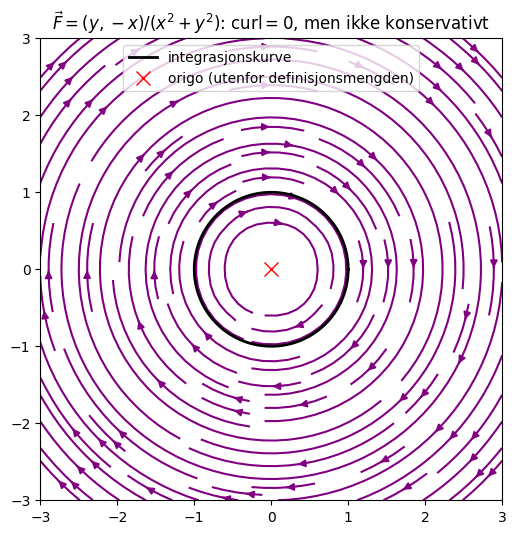

In [8]:
P_num_v = sp.lambdify((x, y), P_v, 'numpy')
Q_num_v = sp.lambdify((x, y), Q_v, 'numpy')

xv = np.linspace(-3, 3, 15)
yv = np.linspace(-3, 3, 15)
X, Y = np.meshgrid(xv, yv)

theta_kurve = np.linspace(0, 2*np.pi, 200)

fig, ax = plt.subplots(figsize=(6, 6))
ax.streamplot(xv, yv, P_num_v(X, Y), Q_num_v(X, Y), color='purple', density=1.2)
ax.plot(np.cos(theta_kurve), np.sin(theta_kurve), color='black', lw=2, label='integrasjonskurve')
ax.plot(0, 0, 'x', color='red', ms=10, label='origo (utenfor definisjonsmengden)')
ax.set_title(r"$\vec F=(y,-x)/(x^2+y^2)$: curl$=0$, men ikke konservativt")
ax.set_aspect('equal')
ax.legend()
plt.show()

**Oppgave (løses i forelesningen):** Bruk `finn_potensial` på $\vec F(x,y)=(3x^2y,\,x^3+2y)$. Finnes det et potensial? Er feltet konservativt? Sjekk svaret ved å derivere det tilbake.

In [9]:
# Skriv koden her


## Oppsummering

1. **Linjeintegralet** av et vektorfelt $\vec F$ langs en kurve $\gamma(t)$, $t\in[a,b]$, er $\int_C\vec F\cdot d\vec r=\int_a^b\vec F(\gamma(t))\cdot\gamma'(t)\,dt$. For et generelt felt avhenger svaret av hvilken kurve vi velger, selv mellom samme to endepunkt.
2. For et **gradientfelt** $\vec F=\nabla f$ er linjeintegralet alltid stiuavhengig: $\int_C\nabla f\cdot d\vec r=f(B)-f(A)$, uansett hvilken kurve $C$ fra $A$ til $B$ vi velger (hovedsetningen for linjeintegraler).
3. Et **konservativt vektorfelt** er et felt der linjeintegralet mellom to punkter alltid er stiuavhengig -- ekvivalent med at $\oint_C\vec F\cdot d\vec r=0$ for enhver lukket kurve $C$, og ekvivalent med at $\vec F=\nabla f$ for en potensialfunksjon $f$.
4. $\operatorname{curl}\vec F=0$ er en **nødvendig**, men ikke alltid **tilstrekkelig** betingelse for at $\vec F$ skal være konservativt -- jamfør Eksempel 2.8 i kompendiet, der curl$=0$ overalt, men linjeintegralet rundt origo likevel er $-2\pi\neq0$. Betingelsen er tilstrekkelig når definisjonsmengden er enkeltsammenhengende (uten hull).

Dette bygger direkte på potensialfunksjoner og rotasjonsfrie felt fra `F12_Potensialfunksjoner_Stromlinjer.ipynb`, og på divergens/curl fra `F11_Gradient_Vektorfelt_Divergens_Curl.ipynb`.